# Utilities

In [256]:
import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [257]:
from Utils.Config import ExperimentResult
from pprint import pprint


json_path = Path("Cache/MetaData/trial_0034/experiment_summary.json")

with open(json_path, "r", encoding="utf-8") as f:
    raw = json.load(f)

exp = ExperimentResult.from_jsonable(raw)

pprint(exp)

ExperimentResult(transform_hparams=TransformHyperParams(resize_size=256,
                                                        p=1.0,
                                                        prefix='resizecrop',
                                                        bilateral_d=11,
                                                        sigma_color=170,
                                                        sigma_space=75,
                                                        gaussian_k=11,
                                                        gaussian_sigma=2.0,
                                                        nlmeans_h=20,
                                                        template_window_size=11,
                                                        search_window_size=11,
                                                        gray_alpha=1.0,
                                                        grid_size=6,
                                                    

# 0. Config

In [258]:
ROOT = Path("Cache/MetaData")  # trial folders root
SAVE_DIR = Path("analysis_outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

PERTURB_TO_FEATURE = {
    "localwarp": "shape",
    "patchshuffle": "shape",
    "patchrotation": "shape",
    "grayscale": "color",
    "bilateral": "texture",
    "bilateralfilter": "texture",
    "original": "clean",
    "none": "clean",
}


# 1. Utilities

In [259]:
def normalize_perturbation(name):
    name = str(name).lower().replace("_", "").replace("-", "")

    if name in {"original", "clean", "none"}:
        return "original"
    if "localwarp" in name:
        return "localwarp"
    if "patchshuffle" in name:
        return "patchshuffle"
    if "patchrotation" in name or "patchrotate" in name:
        return "patchrotation"
    if "gray" in name:
        return "grayscale"
    if "bilateral" in name:
        return "bilateral"

    return name


def parse_scenario_key(key):
    if "__" not in str(key):
        return None, None

    dataset, perturb = str(key).split("__", 1)
    return dataset, normalize_perturbation(perturb)


def make_scenario_key(dataset, perturbation):
    return f"{dataset}__{normalize_perturbation(perturbation)}"


def pick(d, *keys, default=np.nan):
    for k in keys:
        if isinstance(d, dict) and k in d:
            return d[k]
    return default


def build_dataset_meta(summary):
    return {
        ds["name"]: ds
        for ds in summary.get("data_config", {}).get("datasets", [])
    }


def has_validation_metrics(d):
    if not isinstance(d, dict):
        return False

    metric_keys = {
        "LV_ratio", "HFE_ratio", "ESSIM", "GC", "gc",
        "texture_score", "shape_score",
    }

    return any(k in d for k in metric_keys)


def extract_validation_metrics(obj):
    if not isinstance(obj, dict):
        return {}

    if has_validation_metrics(obj):
        return obj

    wrapper_keys = [
        "metrics",
        "scores",
        "result",
        "results",
        "validation",
        "validation_metrics",
        "perturbation_metrics",
    ]

    for key in wrapper_keys:
        if key in obj and isinstance(obj[key], dict):
            found = extract_validation_metrics(obj[key])
            if found:
                return found

    return {}


def find_validation_metrics(perturb_val, perturbation):
    """
    Find validation metrics from the actual JSON structure.

    Expected current case:
        perturbation_validation[perturbation] = {...}

    Also supports:
        perturbation_validation["results"][perturbation] = {...}
        perturbation_validation["records"][i]["perturbation"] = perturbation
        perturbation_validation[perturbation]["metrics"] = {...}
    """
    perturbation = normalize_perturbation(perturbation)

    if not perturb_val:
        return {}

    # Case 1: direct perturbation key
    if isinstance(perturb_val, dict):
        for key, value in perturb_val.items():
            if normalize_perturbation(key) == perturbation:
                found = extract_validation_metrics(value)
                if found:
                    return found

        # Case 2: common nested containers
        container_keys = [
            "results",
            "records",
            "items",
            "validations",
            "perturbations",
            "perturbation_results",
            "perturbation_validation",
            "validation_results",
        ]

        for key in container_keys:
            if key not in perturb_val:
                continue

            container = perturb_val[key]

            if isinstance(container, dict):
                for sub_key, value in container.items():
                    if normalize_perturbation(sub_key) == perturbation:
                        found = extract_validation_metrics(value)
                        if found:
                            return found

            if isinstance(container, list):
                for item in container:
                    if not isinstance(item, dict):
                        continue

                    item_perturb = pick(
                        item,
                        "perturbation",
                        "perturb",
                        "name",
                        "transform",
                        "transform_name",
                        default=None,
                    )

                    if item_perturb is not None and normalize_perturbation(item_perturb) == perturbation:
                        found = extract_validation_metrics(item)
                        if found:
                            return found

        # Case 3: recursive fallback
        for value in perturb_val.values():
            if isinstance(value, dict):
                found = find_validation_metrics(value, perturbation)
                if found:
                    return found

            if isinstance(value, list):
                for item in value:
                    if not isinstance(item, dict):
                        continue

                    item_perturb = pick(
                        item,
                        "perturbation",
                        "perturb",
                        "name",
                        "transform",
                        "transform_name",
                        default=None,
                    )

                    if item_perturb is not None and normalize_perturbation(item_perturb) == perturbation:
                        found = extract_validation_metrics(item)
                        if found:
                            return found

    if isinstance(perturb_val, list):
        for item in perturb_val:
            if not isinstance(item, dict):
                continue

            item_perturb = pick(
                item,
                "perturbation",
                "perturb",
                "name",
                "transform",
                "transform_name",
                default=None,
            )

            if item_perturb is not None and normalize_perturbation(item_perturb) == perturbation:
                found = extract_validation_metrics(item)
                if found:
                    return found

    return {}


def build_scenario_df(summary, json_path):
    trial_id = json_path.parent.name
    hparams = summary.get("transform_hparams", {})
    dataset_meta = build_dataset_meta(summary)

    rows = []

    for scenario in summary.get("scenarios", []):
        dataset = pick(scenario, "dataset_name", "dataset")
        perturbation = normalize_perturbation(
            pick(scenario, "perturbation", default="original")
        )
        scenario_key = make_scenario_key(dataset, perturbation)
        ds_info = dataset_meta.get(dataset, {})

        rows.append({
            "trial_id": trial_id,
            "trial_path": str(json_path),

            "scenario_key": scenario_key,
            "dataset": dataset,
            "perturbation": perturbation,

            "dataset_type": ds_info.get("dataset_type", np.nan),
            "domain_type": ds_info.get("domain_type", np.nan),
            "shift_type": ds_info.get("shift_type", np.nan),
            "num_classes": ds_info.get("num_classes", np.nan),

            "feature_type": PERTURB_TO_FEATURE.get(perturbation, "unknown"),

            "alpha": hparams.get("alpha_localwarp", np.nan),
            "sigma": hparams.get("sigma_localwarp", np.nan),
            "grid_size": hparams.get("grid_size", np.nan),
        })

    scenario_df = pd.DataFrame(rows)

    if scenario_df.empty:
        seen = set()

        for model_result in summary.get("model_results", {}).values():
            for raw_scenario_key in model_result.get("scenario_results", {}).keys():
                dataset, perturbation = parse_scenario_key(raw_scenario_key)

                if dataset is None:
                    continue

                perturbation = normalize_perturbation(perturbation)
                scenario_key = make_scenario_key(dataset, perturbation)

                if scenario_key in seen:
                    continue

                seen.add(scenario_key)
                ds_info = dataset_meta.get(dataset, {})

                rows.append({
                    "trial_id": trial_id,
                    "trial_path": str(json_path),

                    "scenario_key": scenario_key,
                    "dataset": dataset,
                    "perturbation": perturbation,

                    "dataset_type": ds_info.get("dataset_type", np.nan),
                    "domain_type": ds_info.get("domain_type", np.nan),
                    "shift_type": ds_info.get("shift_type", np.nan),
                    "num_classes": ds_info.get("num_classes", np.nan),

                    "feature_type": PERTURB_TO_FEATURE.get(perturbation, "unknown"),

                    "alpha": hparams.get("alpha_localwarp", np.nan),
                    "sigma": hparams.get("sigma_localwarp", np.nan),
                    "grid_size": hparams.get("grid_size", np.nan),
                })

        scenario_df = pd.DataFrame(rows)

    return scenario_df


def build_validation_df(summary, json_path, scenario_df):
    """
    One row = trial_id + perturbation

    validation is currently measured on ImageNet-1K by default.
    dataset column is kept for future dataset-specific validation.
    """
    trial_id = json_path.parent.name
    perturb_val = summary.get("perturbation_validation") or {}
    hparams = summary.get("transform_hparams", {})

    alpha = hparams.get("alpha_localwarp", np.nan)
    sigma = hparams.get("sigma_localwarp", np.nan)
    grid_size = hparams.get("grid_size", np.nan)

    rows = []

    perturbations = (
        scenario_df["perturbation"]
        .dropna()
        .map(normalize_perturbation)
        .unique()
        .tolist()
        if "perturbation" in scenario_df.columns
        else []
    )

    for perturbation in perturbations:
        metrics = find_validation_metrics(perturb_val, perturbation)

        rows.append({
            "trial_id": trial_id,
            "trial_path": str(json_path),

            "dataset": "imagenet",

            "perturbation": perturbation,
            "controlled_perturbation": perturbation if perturbation != "original" else "none",

            "alpha": alpha,
            "sigma": sigma,
            "grid_size": grid_size,

            "LV_ratio": metrics.get("LV_ratio", np.nan),
            "HFE_ratio": metrics.get("HFE_ratio", np.nan),
            "ESSIM": metrics.get("ESSIM", np.nan),
            "GC": metrics.get("GC", metrics.get("gc", np.nan)),
            "texture_score": metrics.get("texture_score", np.nan),
            "shape_score": metrics.get("shape_score", np.nan),
        })

    return pd.DataFrame(rows)


def build_result_df(summary, json_path):
    trial_id = json_path.parent.name
    rows = []

    for model_key, model_result in summary.get("model_results", {}).items():
        model_name = model_result.get("model_name", model_key)
        pretrained = model_result.get("pretrained_weight", np.nan)

        for raw_scenario_key, rec in model_result.get("scenario_results", {}).items():
            key_dataset, key_perturbation = parse_scenario_key(raw_scenario_key)

            dataset = pick(rec, "dataset_name", "dataset", default=key_dataset)
            perturbation = normalize_perturbation(
                pick(rec, "perturbation", default=key_perturbation)
            )
            scenario_key = make_scenario_key(dataset, perturbation)

            rows.append({
                "trial_id": trial_id,
                "trial_path": str(json_path),

                "model_key": model_key,
                "model": model_name,
                "pretrained": pretrained,

                "scenario_key": scenario_key,
                "raw_scenario_key": raw_scenario_key,
                "dataset": dataset,
                "perturbation": perturbation,

                "accuracy": pick(rec, "accuracy", "perturbed_accuracy"),
                "relative_accuracy": pick(
                    rec,
                    "relative_accuracy",
                    "relative_accuracy_score",
                    "rel_accuracy",
                    "rel_acc",
                ),
                "js": pick(rec, "js", "js_divergence"),
                "cka": pick(rec, "cka"),
                "drop_same": pick(
                    rec,
                    "drop_same",
                    "accuracy_drop_vs_same_dataset_clean",
                ),
                "drop_id": pick(
                    rec,
                    "drop_id",
                    "accuracy_drop_vs_id_clean",
                ),
            })

    return pd.DataFrame(rows)


def parse_one_json(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        summary = json.load(f)

    scenario_df = build_scenario_df(summary, json_path)
    validation_df = build_validation_df(summary, json_path, scenario_df)
    result_df = build_result_df(summary, json_path)

    master_df = (
        result_df
        .merge(
            scenario_df.drop(columns=["trial_path"], errors="ignore"),
            on=["trial_id", "scenario_key", "dataset", "perturbation"],
            how="left",
        )
        .merge(
            validation_df.drop(columns=["trial_path"], errors="ignore"),
            on=["trial_id", "perturbation"],
            how="left",
        )
    )

    return {
        "scenario_df": scenario_df,
        "validation_df": validation_df,
        "result_df": result_df,
        "master_df": master_df,
    }


def make_master_dataframe(
    root_dir=Path("Cache/MetaData"),
    save_dir=Path("analysis_outputs"),
    save_csv=True,
):
    save_dir.mkdir(parents=True, exist_ok=True)

    scenario_list = []
    validation_list = []
    result_list = []
    master_list = []

    for json_path in root_dir.rglob("experiment_summary.json"):
        try:
            parsed = parse_one_json(json_path)

            scenario_list.append(parsed["scenario_df"])
            validation_list.append(parsed["validation_df"])
            result_list.append(parsed["result_df"])
            master_list.append(parsed["master_df"])

        except Exception as e:
            print(f"[WARN] {json_path}: {e}")

    scenario_df = pd.concat(scenario_list, ignore_index=True) if scenario_list else pd.DataFrame()
    validation_df = pd.concat(validation_list, ignore_index=True) if validation_list else pd.DataFrame()
    result_df = pd.concat(result_list, ignore_index=True) if result_list else pd.DataFrame()
    master_df = pd.concat(master_list, ignore_index=True) if master_list else pd.DataFrame()

    # Columns to rename from merge suffixes
    rename_map = {
        "dataset_x": "dataset",
        "alpha_x": "alpha",
        "sigma_x": "sigma",
        "grid_size_x": "grid_size",
    }

    # Columns to drop
    drop_cols = [
        # duplicated by merge
        "dataset_y",
        "alpha_y",
        "sigma_y",
        "grid_size_y",

        # implementation-only metadata
        "dataset_type",
        "raw_scenario_key",

        # optional: keep only if you need debugging
        # "trial_path",
    ]


    master_df = master_df.rename(columns=rename_map).drop(columns=drop_cols, errors="ignore")

    num_cols = [
        "num_classes", "alpha", "sigma", "grid_size",
        "accuracy", "relative_accuracy", "js", "cka",
        "drop_same", "drop_id",
        "LV_ratio", "HFE_ratio", "ESSIM", "GC",
        "texture_score", "shape_score",
    ]

    for df in [scenario_df, validation_df, result_df, master_df]:
        for col in num_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

    if "relative_accuracy" in master_df.columns:
        master_df["feature_reliance"] = 1.0 - master_df["relative_accuracy"]

    if "perturbation" in master_df.columns:
        master_df["is_localwarp"] = master_df["perturbation"].eq("localwarp")

    if save_csv:
        scenario_df.to_csv(save_dir / "scenario.csv", index=False)
        validation_df.to_csv(save_dir / "validation.csv", index=False)
        result_df.to_csv(save_dir / "result.csv", index=False)
        master_df.to_csv(save_dir / "master.csv", index=False)

    print("scenario_df:", scenario_df.shape)
    print("validation_df:", validation_df.shape)
    print("result_df:", result_df.shape)
    print("master_df:", master_df.shape)

    if not validation_df.empty:
        print("\nvalidation missing ratio:")
        display(validation_df[[
            "LV_ratio", "HFE_ratio", "ESSIM", "GC",
            "texture_score", "shape_score"
        ]].isna().mean())

    if not master_df.empty:
        display(master_df.head())

    return {
        "scenario_df": scenario_df,
        "validation_df": validation_df,
        "result_df": result_df,
        "master_df": master_df,
    }

In [260]:
result_df = make_master_dataframe(root_dir=ROOT, save_dir=SAVE_DIR)
master_df = result_df["master_df"]
validation_df = result_df["validation_df"]
scenario_df = result_df["scenario_df"]


master_df.head()

scenario_df: (630, 13)
validation_df: (210, 14)
result_df: (1260, 15)
master_df: (1260, 30)

validation missing ratio:


LV_ratio         0.166667
HFE_ratio        0.166667
ESSIM            0.166667
GC               0.166667
texture_score    0.166667
shape_score      0.166667
dtype: float64

,trial_id,trial_path,model_key,model,pretrained,scenario_key,dataset,perturbation,accuracy,relative_accuracy,...,grid_size,controlled_perturbation,LV_ratio,HFE_ratio,ESSIM,GC,texture_score,shape_score,feature_reliance,is_localwarp
0,trial_0026,Cache/MetaData/trial_0026/experiment_summary.json,resnet50__in1k,resnet50,in1k,imagenet__original,imagenet,original,0.79298,NaN,...,6,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,trial_0026,Cache/MetaData/trial_0026/experiment_summary.json,resnet50__in1k,resnet50,in1k,imagenet__grayscale,imagenet,grayscale,0.70596,0.890124,...,6,grayscale,0.999999,1.000000,1.000000,1.000000,0.999999,1.000000,0.109876,False
2,trial_0026,Cache/MetaData/trial_0026/experiment_summary.json,resnet50__in1k,resnet50,in1k,imagenet__bilateral,imagenet,bilateral,0.61658,0.777267,...,6,bilateral,0.531086,0.469517,0.544154,0.860908,0.500302,0.702531,0.222733,False
3,trial_0026,Cache/MetaData/trial_0026/experiment_summary.json,resnet50__in1k,resnet50,in1k,imagenet__patchshuffle,imagenet,patchshuffle,0.56990,0.718326,...,6,patchshuffle,0.999991,0.999992,0.223862,0.095280,0.999991,0.159571,0.281674,False
4,trial_0026,Cache/MetaData/trial_0026/experiment_summary.json,resnet50__in1k,resnet50,in1k,imagenet__patchrotation,imagenet,patchrotation,0.35850,0.451400,...,6,patchrotation,0.924874,0.914709,0.363915,0.210613,0.919791,0.287264,0.548600,False


,trial_id,trial_path,model_key,model,pretrained,scenario_key,dataset,perturbation,accuracy,relative_accuracy,...,grid_size,controlled_perturbation,LV_ratio,HFE_ratio,ESSIM,GC,texture_score,shape_score,feature_reliance,is_localwarp
0,trial_0026,Cache/MetaData/trial_0026/experiment_summary.json,resnet50__in1k,resnet50,in1k,imagenet__original,imagenet,original,0.79298,NaN,...,6,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,trial_0026,Cache/MetaData/trial_0026/experiment_summary.json,resnet50__in1k,resnet50,in1k,imagenet__grayscale,imagenet,grayscale,0.70596,0.890124,...,6,grayscale,0.999999,1.000000,1.000000,1.000000,0.999999,1.000000,0.109876,False
2,trial_0026,Cache/MetaData/trial_0026/experiment_summary.json,resnet50__in1k,resnet50,in1k,imagenet__bilateral,imagenet,bilateral,0.61658,0.777267,...,6,bilateral,0.531086,0.469517,0.544154,0.860908,0.500302,0.702531,0.222733,False
3,trial_0026,Cache/MetaData/trial_0026/experiment_summary.json,resnet50__in1k,resnet50,in1k,imagenet__patchshuffle,imagenet,patchshuffle,0.56990,0.718326,...,6,patchshuffle,0.999991,0.999992,0.223862,0.095280,0.999991,0.159571,0.281674,False
4,trial_0026,Cache/MetaData/trial_0026/experiment_summary.json,resnet50__in1k,resnet50,in1k,imagenet__patchrotation,imagenet,patchrotation,0.35850,0.451400,...,6,patchrotation,0.924874,0.914709,0.363915,0.210613,0.919791,0.287264,0.548600,False


# 2. Sanity Check

In [261]:
print(master_df.columns.tolist())

['trial_id', 'trial_path', 'model_key', 'model', 'pretrained', 'scenario_key', 'dataset', 'perturbation', 'accuracy', 'relative_accuracy', 'js', 'cka', 'drop_same', 'drop_id', 'domain_type', 'shift_type', 'num_classes', 'feature_type', 'alpha', 'sigma', 'grid_size', 'controlled_perturbation', 'LV_ratio', 'HFE_ratio', 'ESSIM', 'GC', 'texture_score', 'shape_score', 'feature_reliance', 'is_localwarp']


In [262]:
print(master_df.shape)
print(master_df.columns)
print(master_df.isna().sum())

display(master_df[[
    "dataset",
    "model_key",
    "perturbation",
    "accuracy",
    "drop_same",
    "drop_id"
]].head(20))

(1260, 30)
Index(['trial_id', 'trial_path', 'model_key', 'model', 'pretrained',
       'scenario_key', 'dataset', 'perturbation', 'accuracy',
       'relative_accuracy', 'js', 'cka', 'drop_same', 'drop_id', 'domain_type',
       'shift_type', 'num_classes', 'feature_type', 'alpha', 'sigma',
       'grid_size', 'controlled_perturbation', 'LV_ratio', 'HFE_ratio',
       'ESSIM', 'GC', 'texture_score', 'shape_score', 'feature_reliance',
       'is_localwarp'],
      dtype='object')
trial_id                     0
trial_path                   0
model_key                    0
model                        0
pretrained                   0
scenario_key                 0
dataset                      0
perturbation                 0
accuracy                     0
relative_accuracy          210
js                         210
cka                        210
drop_same                  210
drop_id                      0
domain_type                  0
shift_type                 840
num_classes         

,dataset,model_key,perturbation,accuracy,drop_same,drop_id
0,imagenet,resnet50__in1k,original,0.792980,NaN,0.000000
1,imagenet,resnet50__in1k,grayscale,0.705960,0.087020,0.087020
2,imagenet,resnet50__in1k,bilateral,0.616580,0.176400,0.176400
3,imagenet,resnet50__in1k,patchshuffle,0.569900,0.223080,0.223080
4,imagenet,resnet50__in1k,patchrotation,0.358500,0.434480,0.434480
5,imagenet,resnet50__in1k,localwarp,0.003460,0.789520,0.789520
6,imagenet_200,resnet50__in1k,original,0.931600,NaN,0.000000
7,imagenet_200,resnet50__in1k,grayscale,0.872200,0.059400,0.059400
8,imagenet_200,resnet50__in1k,bilateral,0.811600,0.120000,0.120000
9,imagenet_200,resnet50__in1k,patchshuffle,0.780100,0.151500,0.151500


In [263]:
master_df.groupby(["dataset", "model_key", "perturbation"]).size()

dataset       model_key           perturbation 
imagenet      resnet50__in1k      bilateral        35
                                  grayscale        35
                                  localwarp        35
                                  original         35
                                  patchrotation    35
                                  patchshuffle     35
              vit-b__augreg_in1k  bilateral        35
                                  grayscale        35
                                  localwarp        35
                                  original         35
                                  patchrotation    35
                                  patchshuffle     35
imagenet_200  resnet50__in1k      bilateral        35
                                  grayscale        35
                                  localwarp        35
                                  original         35
                                  patchrotation    35
                                  

# 3. Analysis

## 3.1 Perturbation Validate Check

In [264]:
fixed_df = master_df[master_df["is_localwarp"] == False]

fixed_summary = (
    fixed_df
    .groupby(["model_key", "domain_type", "perturbation", "feature_type"])[
        ["texture_score", "shape_score", "accuracy", "drop_same", "drop_id", "js", "cka", "relative_accuracy", "feature_reliance"]
    ]
    .mean()
    .reset_index()
)

display(fixed_summary)

,model_key,domain_type,perturbation,feature_type,texture_score,shape_score,accuracy,drop_same,drop_id,js,cka,relative_accuracy,feature_reliance
0,resnet50__in1k,id,bilateral,texture,0.500302,0.702531,0.714090,0.148200,0.148200,0.176269,0.604998,0.823881,0.176119
1,resnet50__in1k,id,grayscale,color,0.999999,1.000000,0.789080,0.073210,0.073210,0.103294,0.697306,0.913009,0.086991
2,resnet50__in1k,id,original,clean,NaN,NaN,0.862290,NaN,0.000000,NaN,NaN,NaN,NaN
3,resnet50__in1k,id,patchrotation,shape,0.919878,0.287583,0.476200,0.386090,0.386090,0.383984,0.356390,0.543475,0.456525
4,resnet50__in1k,id,patchshuffle,shape,0.999985,0.159224,0.675000,0.187290,0.187290,0.207302,0.542436,0.777413,0.222587
5,resnet50__in1k,natural_ood,bilateral,texture,0.500302,0.702531,0.395567,0.013300,0.536033,0.271350,0.660586,0.967068,0.032932
6,resnet50__in1k,natural_ood,grayscale,color,0.999999,1.000000,0.375133,0.033733,0.556467,0.200989,0.755620,0.916474,0.083526
7,resnet50__in1k,natural_ood,original,clean,NaN,NaN,0.408867,NaN,0.522733,NaN,NaN,NaN,NaN
8,resnet50__in1k,natural_ood,patchrotation,shape,0.919878,0.287583,0.099900,0.308967,0.831700,0.476458,0.460001,0.234979,0.765021
9,resnet50__in1k,natural_ood,patchshuffle,shape,0.999985,0.159224,0.165667,0.243200,0.765933,0.390992,0.551656,0.397821,0.602179


### 3.1.1 LocalWARP

In [265]:
lw_df = master_df[master_df["is_localwarp"] == True]
lw_summary = (
    lw_df
    .groupby(["model_key", "domain_type", "alpha", "sigma"])[
        ["texture_score", "shape_score", "accuracy", "drop_same", "drop_id", "js", "cka", "relative_accuracy", "feature_reliance"]
    ]
    .mean()
    .reset_index()
)
lw_summary["relative_accuracy"] = lw_summary["relative_accuracy"].clip(0, 1) # ensure relative accuracy is in [0, 1] 현재 1% 초과인 noisy 데이터 존재
display(lw_summary)

,model_key,domain_type,alpha,sigma,texture_score,shape_score,accuracy,drop_same,drop_id,js,cka,relative_accuracy,feature_reliance
0,resnet50__in1k,id,0,0.5,0.999999,1.000000,0.862290,0.000000,0.000000,-2.726921e-12,1.000000,1.000000,0.000000
1,resnet50__in1k,id,0,1.0,0.999999,1.000000,0.862290,0.000000,0.000000,-2.726921e-12,1.000000,1.000000,0.000000
2,resnet50__in1k,id,0,2.0,0.999999,1.000000,0.862290,0.000000,0.000000,-2.726921e-12,1.000000,1.000000,0.000000
3,resnet50__in1k,id,0,3.5,0.999999,1.000000,0.862290,0.000000,0.000000,-2.726921e-12,1.000000,1.000000,0.000000
4,resnet50__in1k,id,0,6.0,0.999999,1.000000,0.862290,0.000000,0.000000,-2.726921e-12,1.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,vit-b__augreg_in1k,natural_ood,80,0.5,0.999600,0.012612,0.007833,0.383100,0.925867,5.197763e-01,0.170551,0.007342,0.992658
136,vit-b__augreg_in1k,natural_ood,80,1.0,0.999203,0.029434,0.008167,0.382767,0.925533,5.421823e-01,0.184367,0.008205,0.991795
137,vit-b__augreg_in1k,natural_ood,80,2.0,0.997474,0.079588,0.011833,0.379100,0.921867,5.231417e-01,0.228984,0.017706,0.982294
138,vit-b__augreg_in1k,natural_ood,80,3.5,0.979284,0.149102,0.029100,0.361833,0.904600,5.174600e-01,0.295824,0.062446,0.937554


In [266]:
lw_summary['relative_accuracy'].max()

np.float64(1.0)

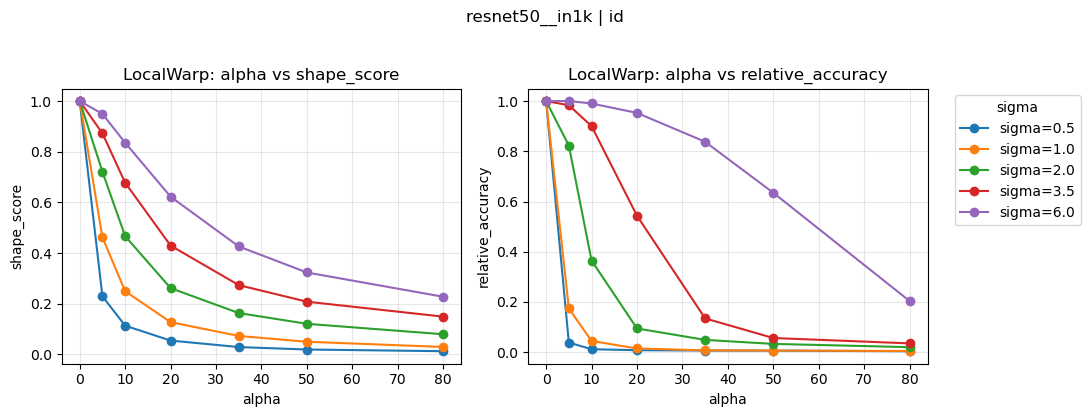

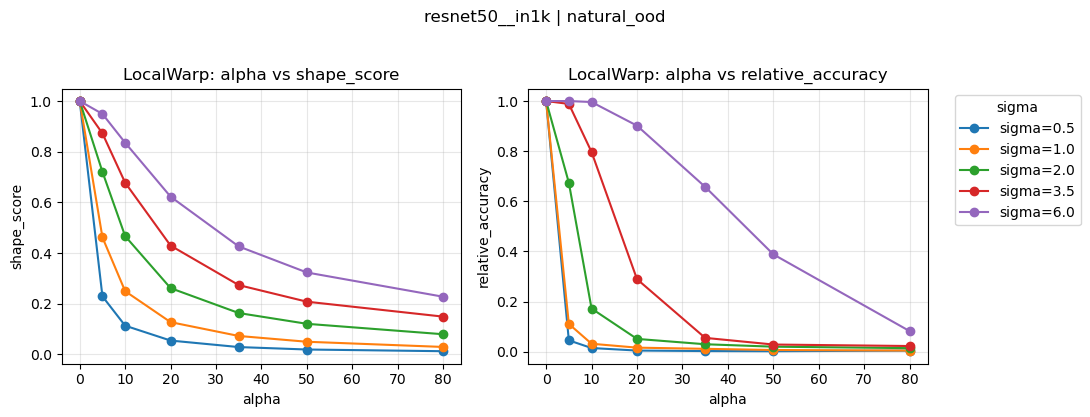

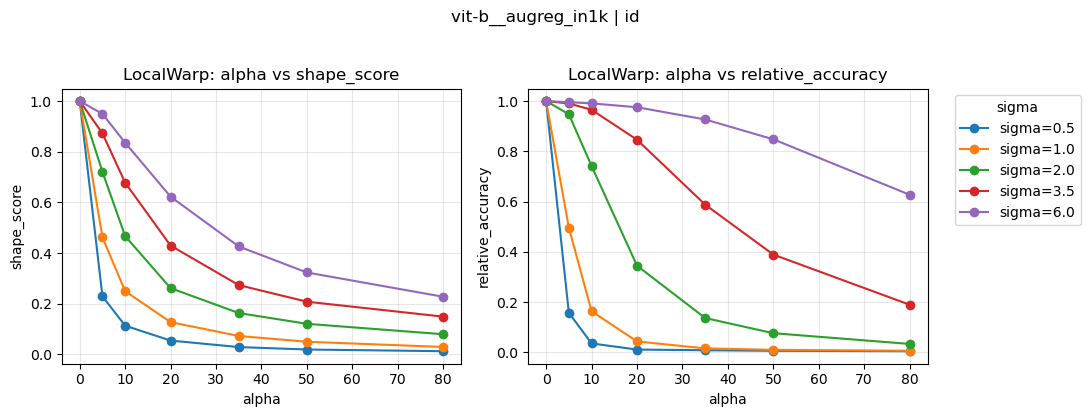

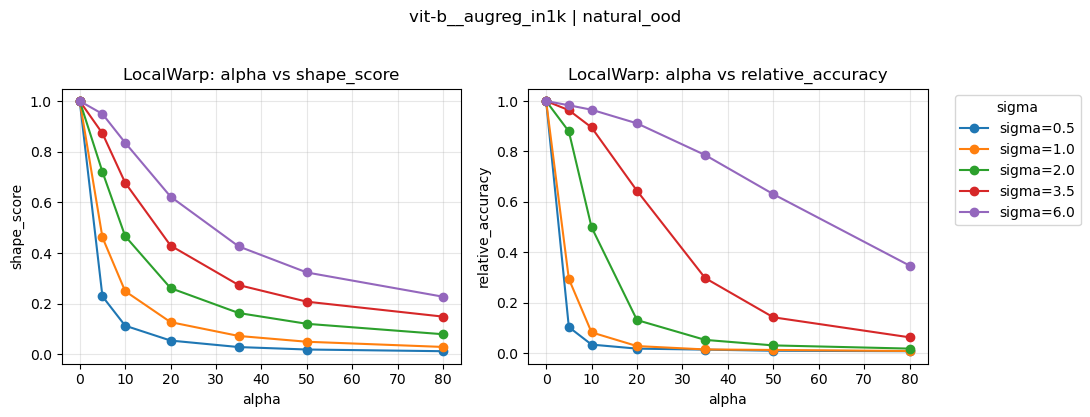

In [267]:
def plot_localwarp_sweep_curves(
    df,
    model_name="resnet50__in1k",
    domain="id",
    model_col="model_key",
    domain_col="domain_type",
    alpha_col="alpha",
    sigma_col="sigma",
    score_col="shape_score",
    perf_col="relative_accuracy",
):
    sub = df[
        (df[model_col] == model_name) &
        (df[domain_col] == domain)
    ].copy()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

    for sigma, s_df in sub.groupby(sigma_col):
        s_df = s_df.sort_values(alpha_col)

        axes[0].plot(
            s_df[alpha_col],
            s_df[score_col],
            marker="o",
            label=f"sigma={sigma}",
        )

        axes[1].plot(
            s_df[alpha_col],
            s_df[perf_col],
            marker="o",
            label=f"sigma={sigma}",
        )

    axes[0].set_title("LocalWarp: alpha vs shape_score")
    axes[0].set_xlabel("alpha")
    axes[0].set_ylabel("shape_score")
    axes[0].grid(alpha=0.3)

    axes[1].set_title(f"LocalWarp: alpha vs {perf_col}")
    axes[1].set_xlabel("alpha")
    axes[1].set_ylabel(perf_col)
    axes[1].grid(alpha=0.3)

    axes[1].legend(title="sigma", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.suptitle(f"{model_name} | {domain}", y=1.03)
    plt.tight_layout()
    plt.show()
    
plot_localwarp_sweep_curves(
    lw_summary,
    model_name="resnet50__in1k",
    domain="id",
    perf_col="relative_accuracy",
)
plot_localwarp_sweep_curves(
    lw_summary,
    model_name="resnet50__in1k",
    domain="natural_ood",
    perf_col="relative_accuracy",
)

plot_localwarp_sweep_curves(
    lw_summary,
    model_name="vit-b__augreg_in1k",
    domain="id",
    perf_col="relative_accuracy",
)
plot_localwarp_sweep_curves(
    lw_summary,
    model_name="vit-b__augreg_in1k",
    domain="natural_ood",
    perf_col="relative_accuracy",
)

In [ ]:
def plot_lw_collapse(
    df,
    score_col="shape_score",
    perf_col="relative_accuracy",   
    model_col="model_key",
    domain_col="domain_type",
    domains=("id", "natural_ood"),
):
    fig, axes = plt.subplots(1, len(domains), figsize=(6 * len(domains), 4), sharey=True)

    if len(domains) == 1:
        axes = [axes]

    for ax, domain in zip(axes, domains):
        domain_df = df[df[domain_col] == domain]
        models = sorted(domain_df[model_col].dropna().unique())

        for model in models:
            sub = domain_df[domain_df[model_col] == model]

            ax.scatter(
                sub[score_col],
                sub[perf_col],
                label=model,
                alpha=0.8,
            )

        ax.set_title(f"{domain.upper()} | {score_col} vs {perf_col}")
        ax.set_xlabel("Shape score")
        ax.set_ylabel(perf_col)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()
    
def pivot_metric(df, value_col, alpha_col="alpha", sigma_col="sigma"):
    return (
        df.pivot_table(
            index=sigma_col,
            columns=alpha_col,
            values=value_col,
            aggfunc="mean",
        )
        .sort_index()
        .sort_index(axis=1)
    )


def _imshow_real_axis(
    ax,
    pivot,
    title,
    xlabel="alpha",
    ylabel="sigma",
    vmin=None,
    vmax=None,
):
    alphas = pivot.columns.to_numpy(dtype=float)
    sigmas = pivot.index.to_numpy(dtype=float)

    im = ax.imshow(
        pivot.values,
        origin="lower",
        aspect="auto",
        extent=[
            alphas.min(),
            alphas.max(),
            sigmas.min(),
            sigmas.max(),
        ],
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticks(alphas)
    ax.set_yticks(sigmas)

    return im


def plot_lw_heatmap(
    df,
    perf_col="relative_accuracy",
    score_col="shape_score",
    model_col="model_key",
    domain_col="domain_type",
    alpha_col="alpha",
    sigma_col="sigma",
    domains=("id", "natural_ood"),
    models=None,
    score_vmin=0.0,
    
    score_vmax=1.0,
    perf_vmin=0.0,
    perf_vmax=1.0,
):
    if models is None:
        models = sorted(df[model_col].dropna().unique())

    assert len(domains) == 2, "2 domains required"
    assert len(models) == 2, "2 models required"

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    for r, domain in enumerate(domains):
        ddf = df[df[domain_col] == domain]

        # (1) shape score
        shape_df = ddf.drop_duplicates(subset=[alpha_col, sigma_col])
        shape_pivot = pivot_metric(shape_df, score_col, alpha_col, sigma_col)

        im = _imshow_real_axis(
            axes[r, 0],
            shape_pivot,
            title=f"{domain.upper()} | {score_col}",
            vmin=score_vmin,
            vmax=score_vmax,
        )
        fig.colorbar(im, ax=axes[r, 0])

        # (2, 3) model performance
        for c, model in enumerate(models, start=1):
            mdf = ddf[ddf[model_col] == model]
            perf_pivot = pivot_metric(mdf, perf_col, alpha_col, sigma_col)

            im = _imshow_real_axis(
                axes[r, c],
                perf_pivot,
                title=f"{domain.upper()} | {model} {perf_col}",
                vmin=perf_vmin,
                vmax=perf_vmax,
            )
            fig.colorbar(im, ax=axes[r, c])

    plt.tight_layout()
    plt.show()
      
def plot_lw_iso(
    df,
    model_name,
    perf_col="rel_acc",
    score_col="shape_score",
    model_col="model_key",
    domain_col="domain_type",
    domain="id",
    alpha_col="alpha",
    sigma_col="sigma",
):
    ddf = df[df[domain_col] == domain]
    mdf = ddf[ddf[model_col] == model_name]

    shape_df = ddf.drop_duplicates(subset=[alpha_col, sigma_col])

    shape_pivot = pivot_metric(shape_df, score_col, alpha_col, sigma_col)
    perf_pivot = pivot_metric(mdf, perf_col, alpha_col, sigma_col)

    alphas = shape_pivot.columns.to_numpy(dtype=float)
    sigmas = shape_pivot.index.to_numpy(dtype=float)
    A, S = np.meshgrid(alphas, sigmas)

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(
        perf_pivot.values,
        origin="lower",
        aspect="auto",
        extent=[alphas.min(), alphas.max(), sigmas.min(), sigmas.max()],
    )

    cs = ax.contour(A, S, shape_pivot.values, levels=5)
    ax.clabel(cs, inline=True, fontsize=8)

    ax.set_title(f"{domain.upper()} | {model_name} ({perf_col})")
    ax.set_xlabel("alpha")
    ax.set_ylabel("sigma")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


### 3.1.2 1D collapse curve (Shape_score vs drop_Acc)

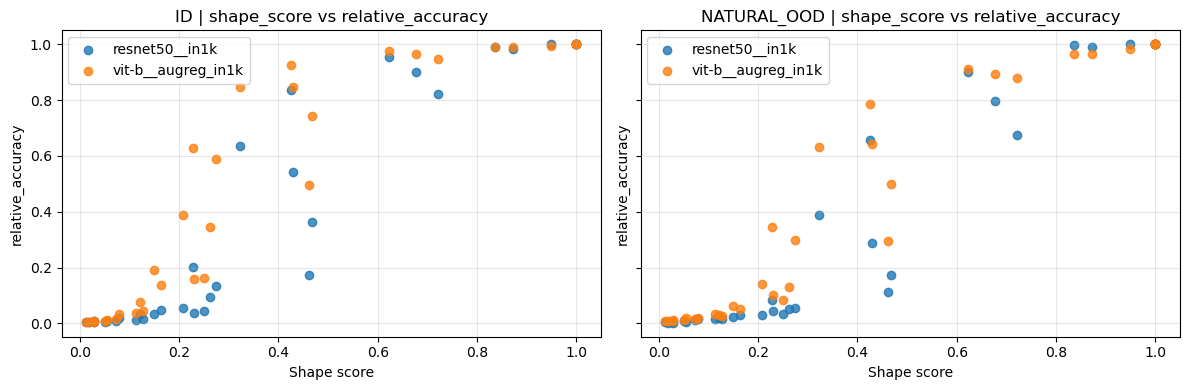

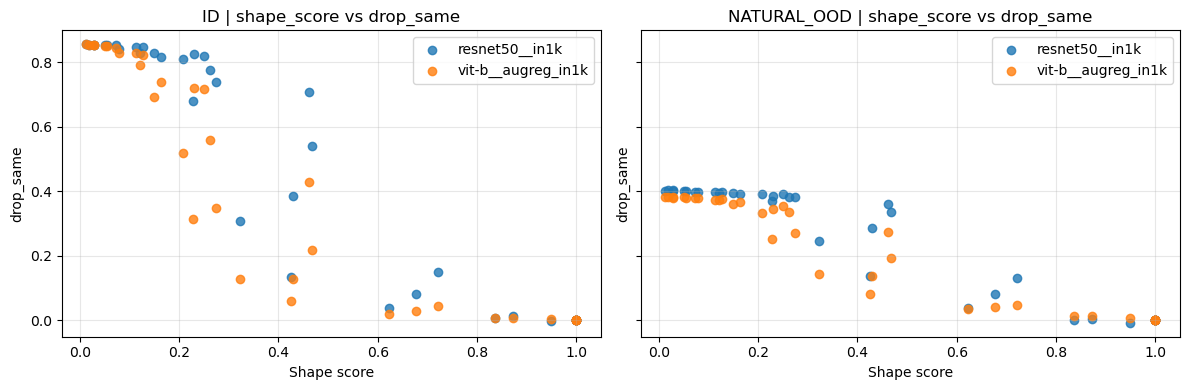

In [269]:
# rel_acc 기반 (논문용)
plot_lw_collapse(lw_summary, perf_col="relative_accuracy")
plot_lw_collapse(lw_summary, perf_col="drop_same")


**Slope**

In [286]:
def slope(x, y):
    m, _ = np.polyfit(x, y, 1)
    return m

shape_base = lw_summary[lw_summary['domain_type'] == 'id']["shape_score"]
relacc_base = lw_summary[lw_summary['domain_type'] == 'id']["relative_accuracy"]
m_base = slope(shape_base, relacc_base)
# m_ours = slope(shape_ours, relacc_ours) #-> 후에 Intervention group 추가하면 비교 가능하도록 
print(f"Shape score vs Relative Accuracy slope (ID): {m_base:.4f}")

shape_base = lw_summary[lw_summary['domain_type'] == 'natural_ood']["shape_score"]
relacc_base = lw_summary[lw_summary['domain_type'] == 'natural_ood']["relative_accuracy"]
m_base = slope(shape_base, relacc_base)
# m_ours = slope(shape_ours, relacc_ours) #-> 후에 Intervention group 추가하면 비교 가능하도록 
print(f"Shape score vs Relative Accuracy slope (ImageNet-R): {m_base:.4f}")

Shape score vs Relative Accuracy slope (ID): 1.1201
Shape score vs Relative Accuracy slope (ImageNet-R): 1.1364


### 3.1.3 HeatMap
- 2D heatmap (X-axis: alpha, Y-axis: sigma Color: Acc or drop_same)
- 2D heatmap (X-axis: alpha, Y-axis: sigma Color: shape score) 

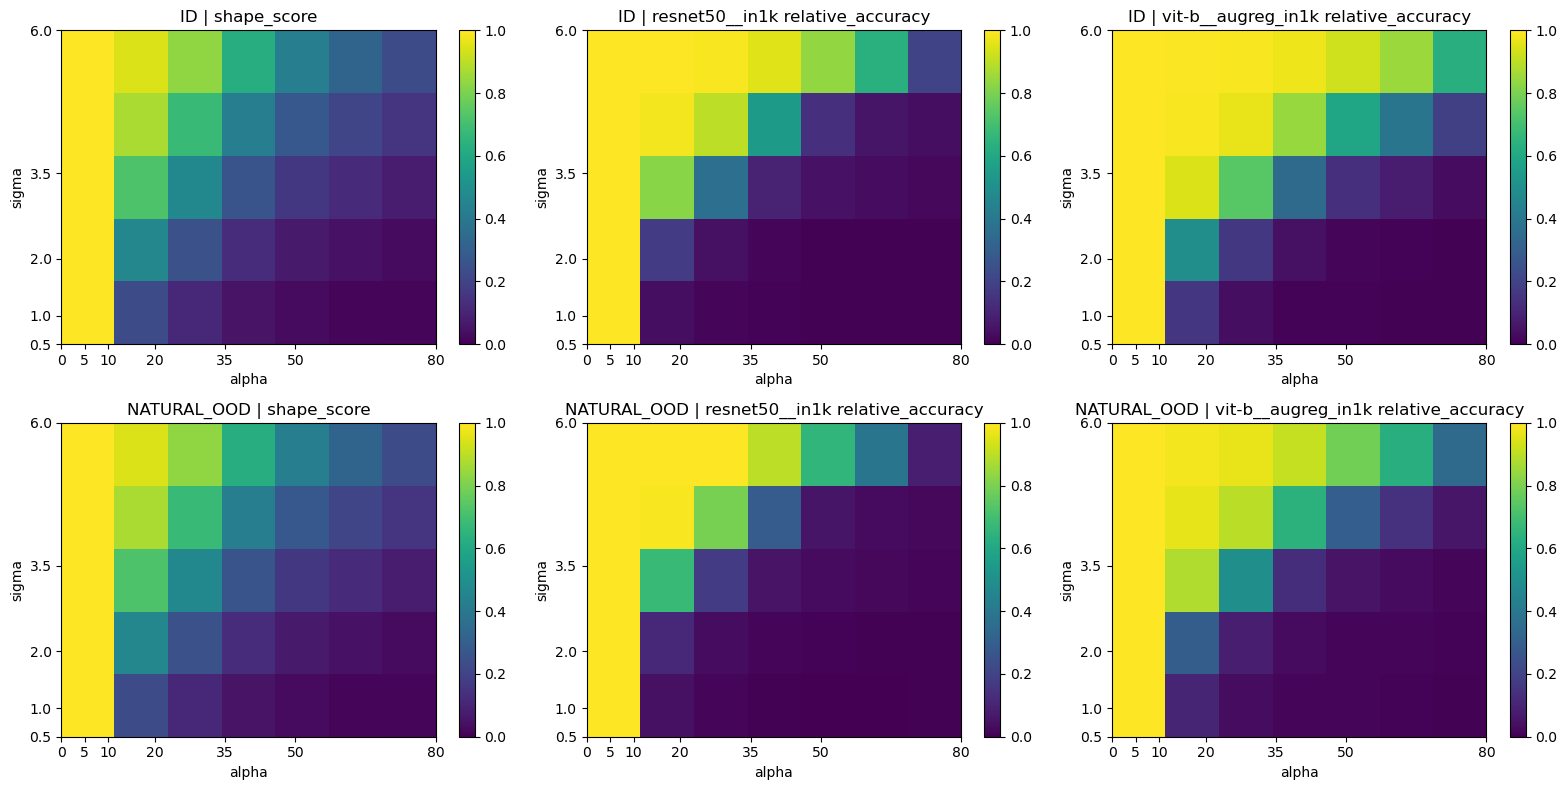

In [270]:
plot_lw_heatmap(lw_summary, perf_col="relative_accuracy")

### 3.1.4 iso-contour
- same shape_score line 따라가면 accuracy도 유사한가?

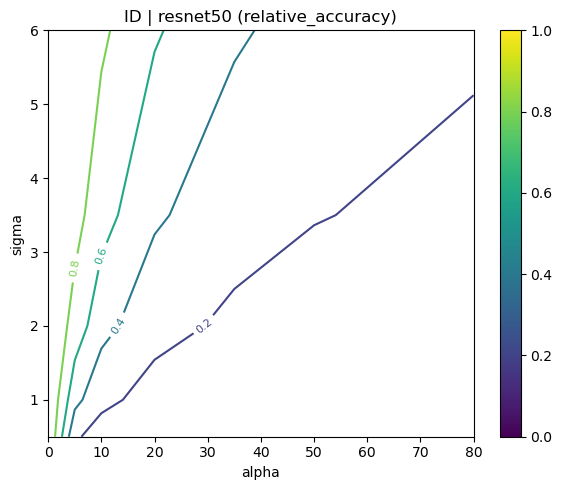

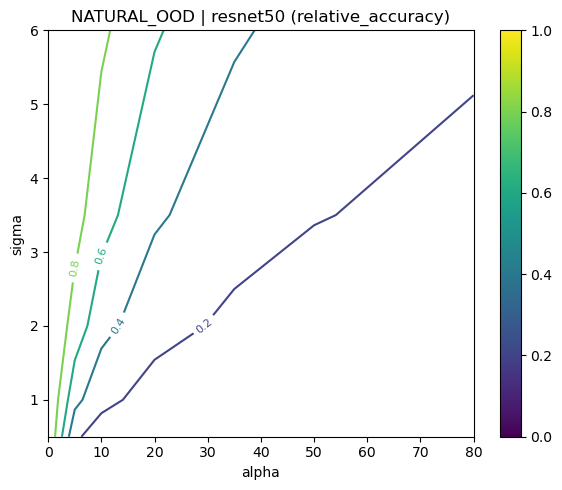

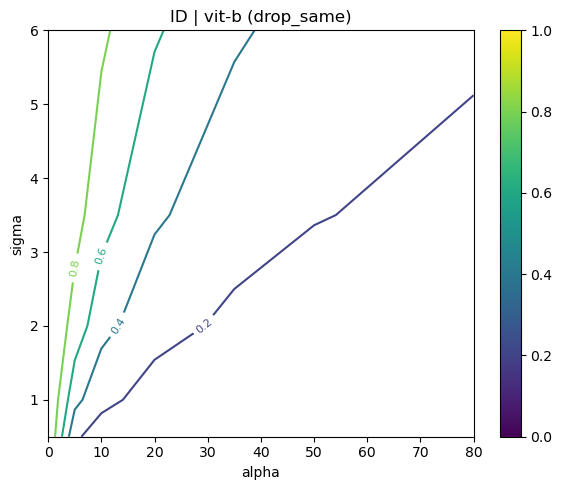

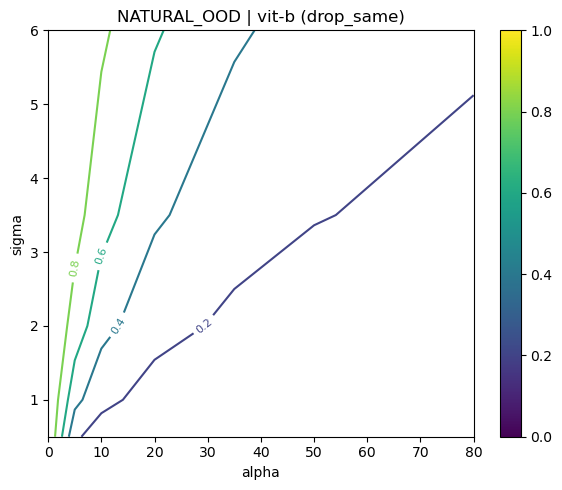

In [271]:
plot_lw_iso(lw_summary, model_name="resnet50", perf_col="relative_accuracy", domain="id")
plot_lw_iso(lw_summary, model_name="resnet50", perf_col="relative_accuracy", domain="natural_ood")

plot_lw_iso(lw_summary, model_name="vit-b", perf_col="drop_same", domain="id")
plot_lw_iso(lw_summary, model_name="vit-b", perf_col="drop_same", domain="natural_ood")

## 3.2 Feature reliance vs OOD accuracy

In [272]:
num_classes = 200
chance = 1.0 / num_classes

id_clean_acc = (
    fixed_summary[
        (fixed_summary["domain_type"] == "id") &
        (fixed_summary["perturbation"] == "original")
    ]
    .set_index("model_key")["accuracy"]
)

ood_clean_acc = (
    fixed_summary[
        (fixed_summary["domain_type"] == "natural_ood") &
        (fixed_summary["perturbation"] == "original")
    ]
    .set_index("model_key")["accuracy"]
)

ood_rel_acc = (ood_clean_acc - chance) / (id_clean_acc - chance)
id_ood_gap = 1.0 - ood_rel_acc

# shape / texture 분리
shape_df = fixed_summary[
    (fixed_summary["feature_type"] == "shape") &
    (fixed_summary["domain_type"] == "id")
]

texture_df = fixed_summary[
    (fixed_summary["feature_type"] == "texture") &
    (fixed_summary["domain_type"] == "id")
]

# 모델별 평균 reliance
shape_rel = shape_df.groupby("model_key")["feature_reliance"].mean()
texture_rel = texture_df.groupby("model_key")["feature_reliance"].mean()

In [273]:
ood_df = fixed_summary[
    (fixed_summary["perturbation"] == "original") &
    (fixed_summary["domain_type"] == "natural_ood")
]

ood_perf = ood_df.set_index("model_key")["accuracy"]

In [274]:
analysis_df = pd.concat(
    [
        shape_rel.rename("shape_rel_id"),
        ood_rel_acc.rename("ood_clean_rel_acc"),
        id_ood_gap.rename("rel_id_ood_gap"),
    ],
    axis=1,
)

display(analysis_df)

,shape_rel_id,ood_clean_rel_acc,rel_id_ood_gap
model_key,,,
resnet50__in1k,0.339556,0.471097,0.528903
vit-b__augreg_in1k,0.324902,0.449989,0.550011


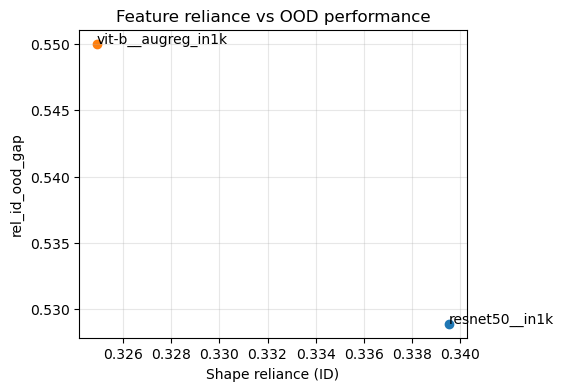

In [275]:
plt.figure(figsize=(5,4))

for model, row in analysis_df.iterrows():
    plt.scatter(row["shape_rel_id"], row["rel_id_ood_gap"])
    plt.text(row["shape_rel_id"], row["rel_id_ood_gap"], model)

plt.xlabel("Shape reliance (ID)")
plt.ylabel("rel_id_ood_gap")
plt.title("Feature reliance vs OOD performance")

plt.grid(alpha=0.3)
plt.show()

## 3.3 feature vulnerability profile

1. 각 모델이 어떤 feature suppression에 가장 취약한가?
2. 그 취약성이 ID/OOD에서 일관적인가?


인지 확인

In [276]:
feature_stats = (
    fixed_summary[
        fixed_summary["perturbation"] != "original"
    ]
    .groupby(["model_key", "domain_type", "feature_type"])["feature_reliance"]
    .agg(["mean", "std"])
    .reset_index()
)

display(feature_stats)



,model_key,domain_type,feature_type,mean,std
0,resnet50__in1k,id,color,0.086991,NaN
1,resnet50__in1k,id,shape,0.339556,0.165419
2,resnet50__in1k,id,texture,0.176119,NaN
3,resnet50__in1k,natural_ood,color,0.083526,NaN
4,resnet50__in1k,natural_ood,shape,0.683600,0.115147
5,resnet50__in1k,natural_ood,texture,0.032932,NaN
6,vit-b__augreg_in1k,id,color,0.119734,NaN
7,vit-b__augreg_in1k,id,shape,0.324902,0.042776
8,vit-b__augreg_in1k,id,texture,0.139588,NaN
9,vit-b__augreg_in1k,natural_ood,color,0.110036,NaN


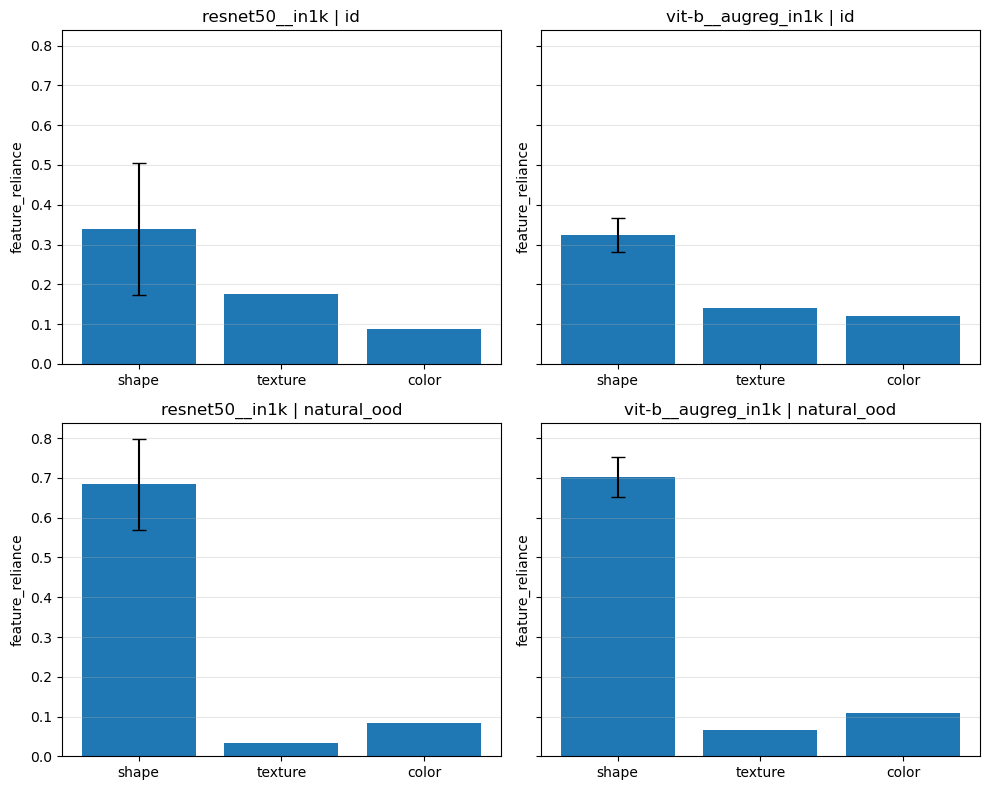

In [277]:

def plot_feature_vulnerability_with_error(feature_stats):
    models = sorted(feature_stats["model_key"].unique())
    domains = sorted(feature_stats["domain_type"].unique())
    features = ["shape", "texture", "color"]

    fig, axes = plt.subplots(
        len(domains),
        len(models),
        figsize=(5 * len(models), 4 * len(domains)),
        sharey=True,
    )

    if len(domains) == 1:
        axes = np.array([axes])
    if len(models) == 1:
        axes = axes.reshape(len(domains), 1)

    for r, domain in enumerate(domains):
        for c, model in enumerate(models):
            ax = axes[r, c]

            sub = feature_stats[
                (feature_stats["model_key"] == model) &
                (feature_stats["domain_type"] == domain)
            ]

            means = []
            stds = []

            for f in features:
                row = sub[sub["feature_type"] == f]
                if len(row) > 0:
                    means.append(row["mean"].values[0])
                    stds.append(row["std"].values[0])
                else:
                    means.append(0)
                    stds.append(0)

            x = np.arange(len(features))

            ax.bar(
                x,
                means,
                yerr=stds,
                capsize=5,
            )

            ax.set_xticks(x)
            ax.set_xticklabels(features)
            ax.set_title(f"{model} | {domain}")
            ax.set_ylabel("feature_reliance")
            ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
    
plot_feature_vulnerability_with_error(feature_stats)